# Week 09 — Home exercise 1: The same chart, two shapes

**Solution proposal.**

One table, two shapes, two ways of drawing the same figure — and the question of which one you keep.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

df = co2.merge(info[["code", "region"]], on="code", how="left", validate="many_to_one")
df = df[df["region"] != "Aggregates"].dropna(subset=["co2_total"])
df["co2_pc"] = df["co2_total"] * 1_000_000 / df["population"]

print(df.shape, "|", df["region"].nunique(), "regions")

(4872, 13) | 7 regions


## 1. The long table

In [2]:
long = df.groupby(["region", "year"])["co2_pc"].mean().reset_index()

print(long.shape)
long.head(3).round(2)

(168, 3)


,region,year,co2_pc
0,East Asia & Pacific,2000,6.42
1,East Asia & Pacific,2001,6.75
2,East Asia & Pacific,2002,5.48


168 rows — seven regions times 24 years — and three columns. One row per region per year.

## 2. Drawing it from the long table

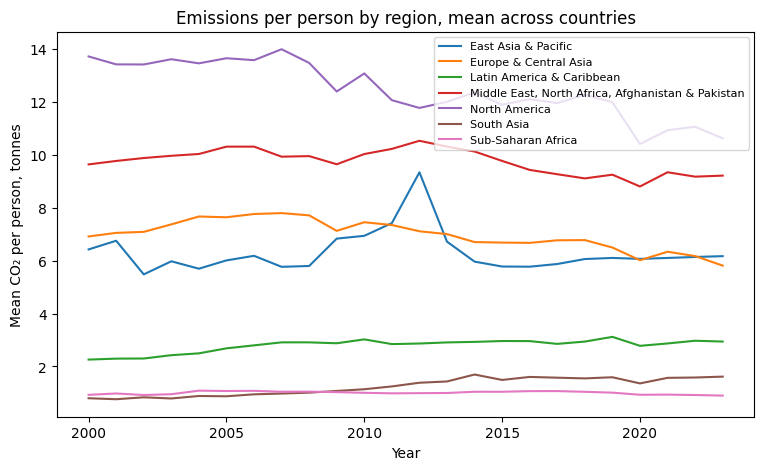

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, group in long.groupby("region"):
    ax.plot(group["year"], group["co2_pc"], label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Mean CO₂ per person, tonnes")
ax.set_title("Emissions per person by region, mean across countries")
ax.legend(fontsize=8);

## 3. The wide table

In [4]:
wide = long.pivot(index="year", columns="region", values="co2_pc")

print("long:", long.shape, "->", long.shape[0], "values")
print("wide:", wide.shape, "->", wide.shape[0] * wide.shape[1], "cells")
wide.iloc[:3, :3].round(2)

long: (168, 3) -> 168 values
wide: (24, 7) -> 168 cells


region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean
year,,,
2000,6.42,6.91,2.26
2001,6.75,7.05,2.29
2002,5.48,7.09,2.30


168 values either way, which is the check worth doing: `pivot` rearranges, it does not compute. If the
two numbers had disagreed, some combination of region and year would have been missing from the long
table and would have arrived in the wide one as a `NaN`.

## 4. Drawing it from the wide table

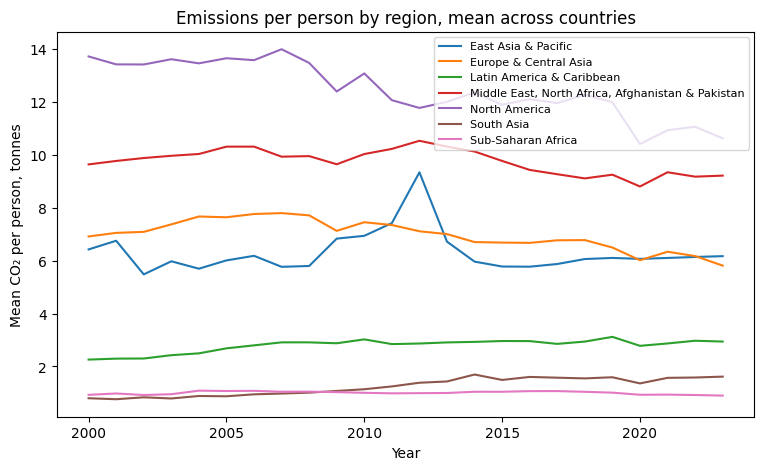

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

wide.plot(ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Mean CO₂ per person, tonnes")
ax.set_title("Emissions per person by region, mean across countries")
ax.legend(fontsize=8);

Identical, and the drawing is one line instead of three. pandas reads the wide table's shape as the
chart's shape: one column, one line, column name as the label.

## 5. Back again

In [6]:
back = wide.reset_index().melt(
    id_vars="year",
    var_name="region",
    value_name="co2_pc",
)

print(back.shape, "| same as the long table:", len(back) == len(long))

(168, 3) | same as the long table: True


## 6. Which would I keep?

### The table

**The long one, every time.**

The reason is not aesthetic. Everything you will want to do to this table afterwards is easier in long
form and some of it is impossible in wide form:

- **Adding a column.** Suppose you now want total emissions beside emissions per person. In the long
  table that is one more column. In the wide table there is nowhere to put it — the columns are already
  spoken for by the regions, and you would need a second table of the same shape.
- **Merging.** Bringing in population, or GDP, or a region lookup, needs a key column to merge on. The
  wide table's keys are its column *names*, and you cannot merge on those.
- **Filtering and grouping.** `long[long["region"] == "South Asia"]` works. The wide equivalent is
  column selection, which is a different operation with different syntax, and `groupby` has nothing to
  group on at all.
- **Adding an eighth region** changes the long table's number of rows and nothing else. It changes the
  wide table's *schema*, and every piece of code that named a column still works while quietly ignoring
  the new one.

The wide table is a **view** of the long one, produced when it is needed and thrown away. That is why
`pivot` is a one-liner: it is meant to be cheap and disposable.

The exception is a table meant for a human to read. Nobody reads 168 rows; everybody can read 24 rows
by 7 columns. Wide is the right shape for a table in a report, which is a different job from a table
on disk.

### The chart cell

**The loop, and this one is closer.**

`wide.plot(ax=ax)` is shorter and there is nothing wrong with it. But the loop is the version that
still works when the question gets harder:

- draw only three of the seven regions
- draw one of them thicker, or in a fixed color
- label them something other than the column name
- skip a group with too few observations

Every one of those is an `if` or an argument inside a loop you already have. In the one-liner each of
them means abandoning it and writing the loop anyway.

So: **the one-liner for looking, the loop for keeping.** When the figure is going into something, you
will end up in the loop, and starting there saves the rewrite.

### Things worth noticing

- **`groupby` produced the long table without being asked to.** Long is not a shape you choose so much
  as the shape pandas hands you, which is a decent argument that it is the natural one.
- **`pivot` needs the aggregation done first.** Calling it on `df` rather than on `long` raises
  `ValueError`, because 37 East Asian countries want the same cell. That error is the library refusing
  to guess, and it is worth being glad of.
- **`melt` is not quite an exact inverse.** It gave back the same 168 rows, but in a different order —
  sorted by region because the wide table's columns were sorted by region. If row order matters to you,
  sort explicitly rather than hoping.

### What this notebook does NOT do

- The regional figures here are **means across countries**, so Tuvalu counts as much as China. The
  lecture showed the other version, and the difference is large. Neither chart says which it is
  anywhere except in the title, which is exactly the weakness being pointed at.
- It never checks whether every region has all 24 years. `pivot` would have filled a hole with `NaN`
  and `ax.plot` would have broken the line — visible here, but only because we happened to be drawing
  lines. A bar chart would have shown nothing at all.